# 8-1. 선형회귀

입력변수에 대한 직선의 방정식을 만들어 예측을 수행하는 방식으로, 예측과 타겟 사이의 평균제곱오차(MSE)를 최소화하는 회귀계수와  
절편을 찾음. 

| **장점**                  | **단점**                          |
| ----------------------- | ------------------------------- |
| 회귀계수를 통해 변수의 영향 해석이 쉬움  | 비선형 관계를 설명하지 못함                 |
| 수학적으로 단순하고 계산이 빠름       | 이상치에 민감함 (MSE 기반)               |
| 통계적 해석 가능 (유의성, 신뢰구간 등) | 다중공선성 발생 시 계수 추정이 불안정함          |
| 과적합 위험이 낮음              | 선형성, 정규성, 등분산성, 독립성 등 엄격한 가정 필요 |
| 복잡한 모델 대비 비교 기준으로 활용 가능 | 변수 간 상호작용이나 복잡한 패턴을 반영하기 어려움    |

**<선형회귀의 가정>**  
- 정규성: 잔차가 정규분포의 형태를 띔
- 등분산성: 독립변수와 무관하게 잔차의 분산이 일정함
- 선형성: 종속변수는 설명변수와 회귀계수의 선형결합으로 표현 가능
- 독립성: 잔차들은 서로 독립, 독립변수들은 서로 선형적으로 독립

| 가정                          | 의미                      | 검정 방법 (추천)                                                   |
| --------------------------- | ----------------------- | ------------------------------------------------------------ |
| **선형성**                     | 설명변수와 종속변수 사이가 선형관계여야 함 | 🔹잔차 vs 예측값 그래프<br>🔹추가변수 플롯 (added variable plot)           |
| **정규성**                     | 잔차가 정규분포를 따라야 함         | 🔹Q-Q plot<br>🔹Shapiro-Wilk 검정<br>🔹Kolmogorov–Smirnov test |
| **등분산성** (Homoscedasticity) | 잔차의 분산이 일정해야 함          | 🔹잔차 vs 예측값 그래프<br>🔹Breusch-Pagan test<br>🔹White test      |
| **독립성**                     | 잔차 간에 자기상관이 없어야 함       | 🔹Durbin-Watson test                                         |



**<전처리>**  
- 이상치에 민감함으로 이상치 처리 필요
- 범주형 변수를 선형식으로 만들기 위해 수치형변수로 변환 필요(더미코딩 등)
  * 원핫인코딩은 다중공선성 문제가 있기 때문에 회귀에서 사용하지 않음
  * 순서가 있는 범주형 변수의 경우, 순서에 따른 수치형 변수로 변환 가능
- 영향치(Influential value) 처리: 회귀모형에서 제외되었을 때 회귀식에 중요한 변화를 가져오는 특정 데이터,  
  잔차의 크기 여부에 상관없이, 회귀결과에 큰 영향을 미치는 경우 회귀에 대해 높은 레버리지를 가짐
  * 척도: Leverage H, Cook's distance, DFBETAS, DFFITS 
- 다중공선성처리: 독립변수들 간에 강한상관관계가 있을 시 선형회귀의 가정인 **독립성 위배**로 회귀계수의 분산이  
  비정상적으로 커져 방정식의 계수 추정에 불안정성을 유발
  * 해결방법: 사전지식 및 직관을 활용하여 상관관계가 높은 독립변수 중 일부 제거, 변수선택법, 분산팽창요인(VIF)를 계산하여 일부 변수 제거  
- 종속변수 스케일링: **잔차분석 결과 등분산성이나 정규성 가정 위반 시**, 종속변수에 Box-cox, 로그변환 등 시도

## 8-1-1. 단순선형회귀
독립변수 X와 종속변수 Y의 정보를 가지고, 일차방정식의 계수와 절편을 찾는 알고리즘

- SST(총제곱합) = SSR(설명가능한 제곱합) + SSE(잔차 제곱합)
- SST: 전체 데이터의 변동(분산)을 나타내는 값으로, 실제 관측값이 평균으로부터 얼마나 퍼져 있는지 측정
- SSR(회귀제곱합): 회귀모형(예측값)이 데이터의 전체 변동 중에서 얼마나 많은 부분을 설명하는지 나타내는 값(모형에 의해 설명되는 분산크기)
- SSE(오차제곱합): 모델이 설명하지 못하고, 실제값과 예측값 사이에 남은 오차(잔차)의 제곱의 합

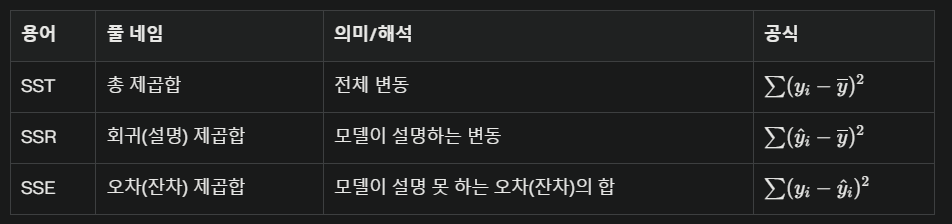

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import koreanize_matplotlib
warnings.filterwarnings('ignore')

data = load_diabetes()

X = data['data']
Y = data['target']

dt = pd.DataFrame(np.c_[X, Y], columns=data['feature_names']+['target'])

#한개의 설명변수와 한개의 종속변수 추출

X = dt['bmi']
Y = dt['target']

print(f"데이터확인: {X[:3].values}, {Y[:3].values}")

데이터확인: [ 0.06169621 -0.05147406  0.04445121], [151.  75. 141.]


최소제곱합이 최소가 되게 하는 w, b를 찾는 것이 목표!

- y(예측값) = w*X + b
- 최소제곱합 = sum((Y(실제값) - y)^2) -> sum((Y - wX - b)^2) 

이 식을 통해 w, b에 대한 편미분 후 각각의 방정식을 통해 다음과 같은 식을 도출한다.

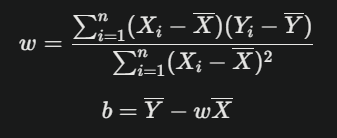

In [2]:
print("[수기적합]")
Xm = X.mean()
Ym = Y.mean()

w =  sum((X-Xm)*(Y-Ym)) / sum((X-Xm)**2) #기울기
b = Ym - w*Xm #절편
print(f"기울기 점추정량: {w:.3f}")
print(f"절편 점추정량: {b:.3f}")
print(f"회귀식: Y = {w:.3f}*X + {b:.3f}")

[수기적합]
기울기 점추정량: 949.435
절편 점추정량: 152.133
회귀식: Y = 949.435*X + 152.133


In [3]:
y = w*X + b #예측값
SSR = sum((y - Ym)**2) #  회귀 제곱합
SSE = sum((Y - y)**2) # 잔차(오차) 제곱합
SST = sum((Y - Ym)**2) # 총 제곱합

R2 = SSR/SST # 회귀식 설명력
R = np.corrcoef(X, Y)[0][1] #상관계수

print(f"결정계수: {R2:.3f}")
print(f"상관계수: {R:.3f}") # 결정계수는 상관계수의 제곱과 같음

결정계수: 0.344
상관계수: 0.586


F 검정은 회귀모형이 오차(잔차)만 있을 때와 비교하여, 모형이 데이터를 얼마나 잘 설명하는지를 "분산의 비"로 평가합니다.

In [4]:
# 회귀계수의 가설검정(F 검정, 유의수준 5%) 
# H0: 모든 회귀계수는 0이다. #H1: 적어도 하나의 회귀계수는 0이 아니다.
from scipy.stats import f

t_df = 1 #설명변수 개수(처리의 자유도)
r_df = len(X) - t_df -1 #잔차의 자유도(전체 데이터 개수 - 설명변수 개수 -1)
MSR = SSR / t_df
MSE = SSE / r_df

fstat = MSR / MSE # f 통계량
p = 1-f.cdf(fstat, t_df, r_df)

print(f"MSE: {MSE:.3f}, MSR: {MSR:.3f}, F 통계량: {fstat:.3f}")
print(f"P-value({t_df}, {r_df}): {p:.3f}", "귀무가설 기각" if p < 0.05 else "귀무가설 기각 x")

MSE: 3908.140, MSR: 901427.314, F 통계량: 230.654
P-value(1, 440): 0.000 귀무가설 기각


In [5]:
#[라이브러리] 검정
import statsmodels.formula.api as smf

train = pd.concat([X, Y], axis=1)
model = smf.ols(formula='target~bmi', data=train).fit()
#sm.OLS(Y, X)
resid = model.resid #잔차

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           3.47e-42
Time:                        16:13:27   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.974     51.162      0.0

- 모형의 유의성: 유의수준 5% 하에서, F-통계량의 p-value가 3.47e-42로 매우 작기 때문에, 전체 회귀모델은 통계적으로 유의하다고 판단된다.
- 설명력 (R²): 결정계수 R²는 0.344로, 종속변수의 약 34.4%만 설명하므로 설명력이 낮은 편이다.
- 변수의 유의성: 유의수준 5% 하에서 bmi 변수의 p-value가 0에 수렴하여 귀무가설을 기각하므로, 해당 변수는 통계적으로 유의하며 회귀계수가 0이 아니다.


In [6]:
#사이킷런 방식
from sklearn.linear_model import LinearRegression

X = np.array(X).reshape(-1, 1) #이치원으로 만들어주어야 함
Y = np.array(Y).reshape(-1, 1) #아니면 에러남

lr = LinearRegression()
lr.fit(X, Y)
pred = lr.predict(X)

print(f"회귀계수: {lr.coef_}")
print(f"절편: {lr.intercept_}")
print(f"결정계수: {lr.score(X, Y)}")

회귀계수: [[949.43526038]]
절편: [152.13348416]
결정계수: 0.3439237602253803


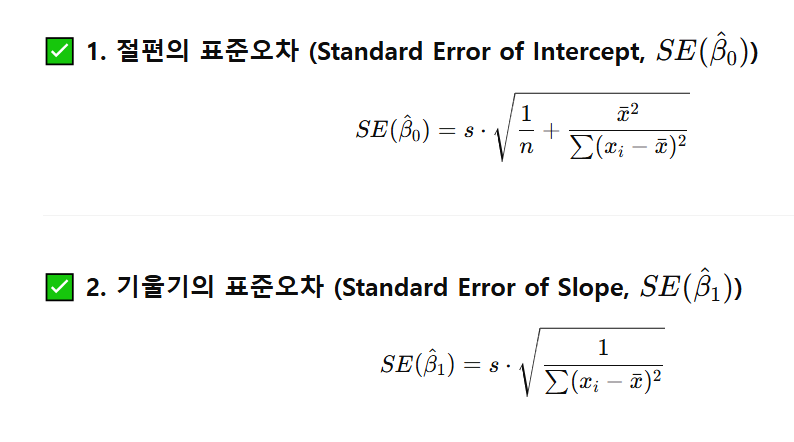

In [7]:
#기울기, 절편, Y의 평균값에 대한 추정과 검정
r_std = np.sqrt(MSE) #잔차의 표준오차
r_std2 = model.resid.std(ddof=2)

print(f"잔차 표준오차: {r_std:.3f}(={r_std2:.3f})")

잔차 표준오차: 62.515(=62.515)


In [8]:
from scipy.stats import t

# 기울기 추정
print(f"기울기 점추정량: {w:.3f}")

SE = r_std / np.sqrt(sum((X-Xm)**2)) # 잔차 표준편차/x편차의 제곱합
print(f"점추정량의 표준오차: {SE[0]:.3f}")

a = 0.05 #유의확률
down = w + t.ppf(a/2, r_df)*SE #하한
up = w + t.ppf(1-a/2, r_df)*SE #상한
print(f"신뢰구간: {down[0]:.3f} ~ {up[0]:.3f}")

#기울기 가설검정
#단순선형회귀에서 회귀계수의 신뢰구간 및 가설검정에 t 분포를 사용하는 이유는,
#잔차(오차)의 분산(σ², 즉 "진짜" 오차의 크기)가 알려져 있지 않고 표본 자료로부터 추정
#H0: 기울기 w는 0이다. / H1: 기울기 w는 0이 아니다.

a = 0.05
w0 = 0
tstat = (w-w0)/SE
p = (1-t.cdf(tstat, r_df))*2

print(f"검정통계량: {tstat[0]:.3f}, p-value: {p[0]:.3f}")
print(f"유의수준 5% 하", "귀무가설 기각" if p < 0.05 else "귀무가설 기각x")

기울기 점추정량: 949.435
점추정량의 표준오차: 62.515
신뢰구간: 826.570 ~ 1072.301
검정통계량: 15.187, p-value: 0.000
유의수준 5% 하 귀무가설 기각


In [9]:
# 절편 추정, 마찬가지로 t 분포 사용

print(f"절편의 점추정량: {b:.3f}")

Xi = 0

SE2 = r_std * np.sqrt(1/len(X)+(Xi-Xm)**2/sum((X-Xm)**2))
print(f"점추정량 표준오차: {SE2[0]:.3f}")

down = b + t.ppf(a/2, r_df)*SE2
up = b + t.ppf(1-a/2, r_df)*SE2
print(f"신뢰구간: {down[0]:.3f} ~ {up[0]:.3f}")


#절편 가설검정
#H0: 절편 b0는 0이다. / H1: 절편 b0는 0이 아니다.

b0 = 0
tstat = (b-b0)/SE2

p = (1-t.cdf(tstat, r_df))*2

print(f"검정통계량: {tstat[0]:.3f}, p-value: {p[0]:.3f}")
print(f"유의수준 5% 하", "귀무가설 기각" if p < 0.05 else "귀무가설 기각x")

절편의 점추정량: 152.133
점추정량 표준오차: 2.974
신뢰구간: 146.289 ~ 157.978
검정통계량: 51.162, p-value: 0.000
유의수준 5% 하 귀무가설 기각


In [10]:
# 특정한 X 값일 때, Y의 평균값

Xi = 0.15

Y2 = b + w*Xi

print(f"X가 {Xi}일 때 Y의 점추정량: {Y2:.3f}")

SE3 = r_std * np.sqrt(1/len(X) + (Xi-Xm)**2/sum((X-Xm)**2))
print(f"점추정량 표준오차: {SE3[0]:.3f}")

down = Y2 + t.ppf(a/2, r_df)*SE3
up = Y2 + t.ppf(1-a/2, r_df)*SE3
print(f"신뢰구간: {down[0]:.3f} ~ {up[0]:.3f}")

# Y 평균값 가설검정
# H0: Y_0는 0이다. / H1: 0이 아니다.
Y0 = 0
tstat = (Y2 - Y0) / SE3
p = (1-t.cdf(tstat, r_df))*2

print(f"검정통계량: {tstat[0]:.3f}, p-value: {p[0]:.3f}")
print(f"유의수준 5% 하", "귀무가설 기각" if p < 0.05 else "귀무가설 기각x")

X가 0.15일 때 Y의 점추정량: 294.549
점추정량 표준오차: 9.837
신뢰구간: 275.215 ~ 313.883
검정통계량: 29.942, p-value: 0.000
유의수준 5% 하 귀무가설 기각


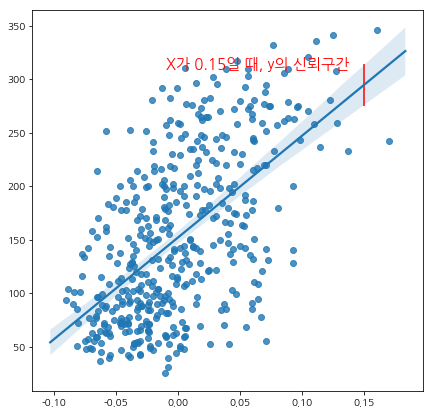

In [11]:
# 회귀직선 신뢰구간대 시각화

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sns.regplot(x=X, y=Y.reshape(-1), ax=ax)
ax.vlines(x=0.15, ymin=down, ymax=up, color='r') # 신뢰구간 표시
ax.text(-0.01, 310, f"X가 {Xi}일 때, y의 신뢰구간", color='r', size=15)
plt.show()

# 8-1.2. 다중선형회귀

In [55]:
X = dt[dt.columns[:4]]
Y = dt['target']

def multi_model(X, Y):
    train = pd.concat([X, Y], axis=1)
    fm = '+'.join(X.columns)
    model = smf.ols(formula=f"target~{fm}", data=train).fit()
#     print(model.summary())
    return model

model = multi_model(X, Y)

- 모형의 유의성: 유의수준 5% 하에서, F-통계량의 p-value가 2.70e-47로 매우 작기 때문에, 전체 회귀모델은 통계적으로 유의하다고 판단된다.  
  (회귀계수 중 적어도 하나는 0이 아님)
- 설명력 (R²): 결정계수 R²는 0.395로, 종속변수의 약 39.5%만 설명하므로 설명력이 낮은 편이다.
- 변수의 유의성: 유의수준 5% 하에서 각 변수의 통계적 유의성 검정
  - age: 0.562 로 귀무가설 기각 불가(계수가 통계적으로 유의하지 않음)
  - bmi: 0으로 귀무가설 기각, 계수가 통계적으로 유의
  - sex: 0.087로 귀무가설 기각불가
  - bp: 귀무가설 기각  
  
**유의한 변수: bmi, bp**

<잔차진단지표>

| 지표                       | 해석                                                      |
| ------------------------ | ------------------------------------------------------- |
| **Durbin-Watson: 1.933** | 잔차 간 **자기상관 거의 없음** (2에 가까움)                            |
| **Omnibus / JB 테스트**     | p < 0.05 → **잔차의 정규성이 다소 부족**할 수 있음. 다만, 큰 문제는 아닐 수 있음. |
| **Cond. No: 28.4**       | 조건수(Condition Number)가 낮아 **다중공선성 문제 없음**으로 보임.         |


| 메서드 또는 속성                     | 설명                             | 의미 및 해석                                                       |
| ----------------------------- | ------------------------------ | ------------------------------------------------------------- |
| **`.summary_frame()`**            | 모든 진단 지표를 하나의 DataFrame으로 반환   | 다양한 이상치 및 영향력 지표를 종합적으로 확인할 수 있음                              |
| **`.cooks_distance`**             | 각 관측치의 Cook's D 값과 p-value를 반환 | 관측치가 전체 회귀계수에 끼치는 **종합적 영향력**. 일반적으로 `> 4/(n-p-1)`이면 영향력 있음         |
| **`.dfbetas`**                    | 각 회귀계수에 대한 관측치의 영향도를 행렬 형태로 반환 | **해당 관측치가 특정 회귀계수에 얼마나 영향을 주는지** 나타냄. 절대값이 `2, > 2/√n`이면 영향   |
| **`.hat_matrix_diag`**            | 각 관측치의 leverage 값 (hat 값)      | 관측치가 회귀선 추정에 기여하는 정도. `2(p+1)/n` 영향력 있는 관측치로 의심됨            |
| `.resid_studentized_internal` | 내부 studentized residuals       | 내부표준화 잔차. 이상치 탐지에 사용되며, 정규성 가정 확인에 유용                         |
| `.resid_studentized_external` | 외부 studentized residuals       | **해당 관측치를 제외한 모델로 계산된 표준화 잔차**. 이상치 탐지에 더 민감                  |
| `.resid`                      | 잔차 (Residuals)                 | 실제값과 예측값의 차이. 잔차의 분포가 정규성을 만족해야 선형회귀 전제 성립                    |
| **`.dffits`**                     | 관측치가 예측값에 끼치는 영향도              | DFFITS 값이 크면 **관측치가 예측값 자체에 큰 영향을 준다는 뜻**. 일반 기준: `> 2√(p+1/n)` |
| `.summary_table()`            | 진단 지표와 회귀 결과를 함께 출력하는 전체 표 반환  | 잔차, 예측값, 표준화된 잔차 등 포함. 시각화나 리포트 생성 시 유용                       |


- .cooks_distance: 레버리지와 잔차의 크기를 합쳐서 영향력 판단, 일반적으로 쿡의 거리가 1보다 클 경우 영향치로 간주
- DFBETAS: 값이 커지면 관측치가 영향치 또는 이상치일 가능성이 높으며, 기준값보가 클 경우 영향치로 간주
- DFFITS: 특정 관측치 제외 시 종속변수 예측치의 변화 정도를 측정한 값

In [13]:
# 각 데이터의 영향치 판단값 계산
rs = model.get_influence().summary_frame() #쿡 일반적으로 1보다 크면 영향치
display(rs.head(3))

,dfb_Intercept,dfb_age,dfb_sex,dfb_bmi,dfb_bp,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,-0.043867,-0.022575,-0.041041,-0.052115,0.017820,0.001516,-0.918300,0.008908,-0.087061,-0.918135,-0.087046
1,-0.024198,-0.007251,0.020893,0.023310,0.000625,0.000350,-0.507449,0.006743,-0.041811,-0.507017,-0.041775
2,-0.033422,-0.059420,-0.031693,-0.032286,0.040674,0.001478,-0.697801,0.014950,-0.085965,-0.697391,-0.085914


| 지표              | 값        | 해석                                                                     |
| --------------- | -------- | ---------------------------------------------------------------------- |
| `cooks_d`       | 0.001516 | $\frac{4}{442-4(설명변수개수)-1} \approx 0.009$보다 작음 → 영향력 없음                            |
| `dfb_bmi`       | -0.0521  | 기준 $\approx \frac{2}{\sqrt{442}} \approx 0.095$보다 작음 → bmi 회귀계수에 영향 없음 |
| `hat_diag`      | 0.0089   | 평균 $p/n \approx 5/442 = 0.011$ → 보통 수준                                 |
| `student_resid` | -0.9181  | ±2보다 작음 → 이상치 아님                                                       |

In [14]:
#영향치로 판단되는 데이터 추출
# 1.cook's distance

p = X.shape[1]
base1 = 4/(len(rs)-p-1)

def find_dt(base, title):
    idx = rs[rs[title] > base].index
    print(f"{title} 영향치 인덱스: {idx.values}")
    return idx

cook = find_dt(base1, 'cooks_d')

#BFBETAS 영향치: 여기서는 잔차
base2 = 2/np.sqrt(len(rs))

bfbetas = find_dt(base2, 'dfb_Intercept')

#dbfits 영향치
base3 = 2*np.sqrt((4+1)/len(rs))
dbfits = find_dt(base3, 'dffits_internal')

#leverage H 기준 영향치
base4 = 2*(4+1)/len(rs)
leverage_h = find_dt(base4, 'hat_diag')

cooks_d 영향치 인덱스: [  9  78  92 102 117 141 147 152 204 211 256 289 328 336 343 380 417]
dfb_Intercept 영향치 인덱스: [  9  37  78 102 141 152 190 218 359 364]
dffits_internal 영향치 인덱스: [  9  78 102 117 141 152 204 256 336]
hat_diag 영향치 인덱스: [ 10  71 130 145 251 256 261 262 278 311 327 340 366 367 407 408 422]


### VIF 계산

분산팽창요인(Variance inflation factor)은 선형회귀에 변수들이 추가되는 경우 매개변수 추정의 분산 증가에 대한 측정치로서  
다중공선성의 척도이다. VIF가 10 이상일 때, 설명변수들이 높은 상관성을 가진다고 본다.

**범주형 변수**가 다중 선형회귀에 포함되어 있을 경우, 더미코딩을 통해 다중공선성 문제를 피할 수 있다.  
회귀모형에 일반적으로 절편이 포함되기 때문에 p-1개의 이진변수의 값을 정의하고 나면, p번째 값을 알 수 있고,   
따라서 p번째 값까지 넣게 되면 이러한 중복성이 문제가 될 수 있기 때문에 p번째 열을 추가하지 않음으로써 다중공선성 오류를 피할 수 있다.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

def c_vif(x, y):
    train = pd.concat([x, y], axis=1)
    ft = '+'.join(x.columns)
    model = smf.ols(formula=f"target~{ft}", data=train).fit()
    vif_df = pd.DataFrame(columns=['feat', 'VIF'])
    vif_df['feat'] = x.columns
    vif_df['VIF'] = [VIF(x.values, i) for i in range(x.shape[1])]
    return vif_df

c_vif(X, Y)

,feat,VIF
0,age,1.142886
1,sex,1.072962
2,bmi,1.189944
3,bp,1.342622


모든 feature의 VIF 가 1에 가깝기 때문에 다중공선성이 없다고 할 수 있다.

### 변수선택과 가능도

변수선택법은 AIC를 최소로 하거나 수정 결정계수를 최대로 하는 변수의 조합을 갖는 최적 회귀식을 찾는 방법  
단계적 선택법, 전진선택법, 후진제거법이 있음

<변수선택기준>
- 수정결정계수: 모델의 변수를 추가할수록 기존 결정계수에 불이익을 주며, 모형의 적합도를 판단하는 척도
  - 1 - (1 - R2)(n - 1)/(n - p -1)
- AIC(Akaike's information criteria): 모델에 변수를 추가할수록 불이익을 주는 오차측정법
  - -2logLi + 2(p + 1) : 절편이 있는 경우 p+1, 없으면 p
- BIC(Bayesian information criteria): AIC 와 비슷하지만 변수 추가에 더 강한 불이익을 줌
  -  -2logLi + log(n)(p+1)
- Mallow Cp: AIC의 변형, Cp 값이 작고, (p+상수의 개수)와 비슷할수록 편향이 작고 우수한 모델이라고 판단함.  
  후보 설명변수들로 적합한 모델의 SSEp와 설명변수로 적합했을 때의 MSE full로 아래와 같이 C p를 구한다.
  - Cp = (SSE p/MSE full) - n + 2(p + 1)
  
<가능도(likelihood): 확률분포의 모수가 어떤 확률변수의 표집값과 일관되는 정도를 나타내는 값>  
주어진 표집값에 대한 모수의 가능도는 이 모수를 따르는 분포가 주어진 관측값에 대해 부여하는 확률로, 어떤 **모델의 가능도가 높을수록  
모델의 추정량이 실제 모수값에 가까움** 가능도 함수는 확률분포가 아니며, 합한 값이 1이 되지 않을 수 있음

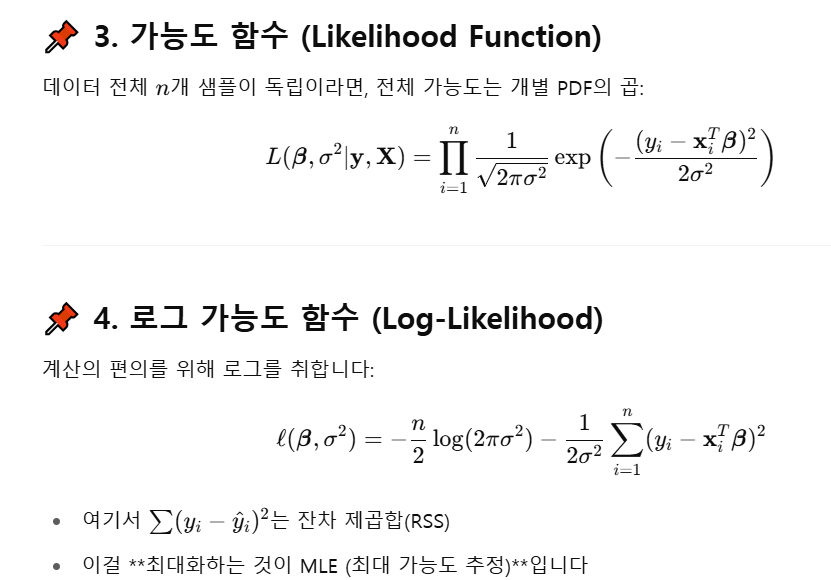


In [30]:
# 모든 변수를 포함한 full model

f_model = multi_model(X, Y)

R2 = f_model.rsquared #R2값
n = X.shape[0] #데이터 개수
p = X.shape[1] #설명변수 개수

SSE = sum((f_model.resid)**2) 
MSE_full = SSE/(n-p-1) 
adj_R2 = 1-(1-R2)*(n-1)/(n-p-1) 
print(f"수정 결정계수: {adj_R2:.3f}")


#수기계산법
llf = -n/2*np.log(2*np.pi) - n/2*np.log(SSE/n) - n/2 #로그가능도 값(fitted.llf)
aic = -2*llf + 2*(p+1)
bic = -2*llf + np.log(n)*(p+1)
cp = SSE/MSE_full - n + 2*(p+1)

print(f"AIC: {aic:.3f}") #model.aic
print(f"BIC: {bic:.3f}") # model.bic
print(f"cp: {cp:.3f} --> 변수+상수 개수: {p+1}") #변수+상수 개수의 합과 같을수록 훌륭한 모델

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.395
Method:                 Least Squares   F-statistic:                     72.91
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           2.70e-47
Time:                        16:54:11   Log-Likelihood:                -2434.2
No. Observations:                 442   AIC:                             4878.
Df Residuals:                     437   BIC:                             4899.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.853     53.329      0.0

In [31]:
#일부 변수만 포함한 후보 model

X2 = X[['bp', 'bmi']]

p_model = multi_model(X2, Y)

R2 = p_model.rsquared #R2값
n = X2.shape[0] #데이터 개수
p = X2.shape[1] #설명변수 개수

SSE2 = sum((p_model.resid)**2) 
adj_R2 = 1-(1-R2)*(n-1)/(n-p-1) 
print(f"수정 결정계수: {adj_R2:.3f}")


#수기계산법
llf = -n/2*np.log(2*np.pi) - n/2*np.log(SSE/n) - n/2 #로그가능도 값(fitted.llf)
aic = -2*llf + 2*(p+1)
bic = -2*llf + np.log(n)*(p+1)
cp = SSE2/MSE_full - n + 2*(p+1) #full 모델의 것 비교

print(f"AIC: {aic:.3f}") #model.aic
print(f"BIC: {bic:.3f}") # model.bic
print(f"cp: {cp:.3f} --> 변수+상수 개수: {p+1}") #변수+상수 개수의 합과 같을수록 훌륭한 모델

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     143.9
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           8.68e-49
Time:                        16:54:27   Log-Likelihood:                -2435.7
No. Observations:                 442   AIC:                             4877.
Df Residuals:                     439   BIC:                             4890.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.856     53.261      0.0

- 수정 결정계수값이 미약하게 상승
- AIC 값이 미약하게 감소
- cp 값이 작아짐(오차가 FULL 모델보다 다소 큼)

부분 모델은 적은 수의 변수로도 비슷하거나 더 나은 설명력을 보여주며, AIC가 더 낮습니다.  
Cp는 약간 기준보다 높지만 큰 차이는 아니므로, 과적합을 피하고 해석 가능한 모델을 원한다면 부분 모델이 더 바람직할 수 있습니다.

In [107]:
# 단계적 선택법
from itertools import combinations

def check_best(X, Y, op='AIC'): #BIC, 'CP', 'adj_R2'
    result = pd.DataFrame(columns=['feat', 'AIC', 'BIC', 'CP', 'adj_R2'])
    feat_combi = []
    
    for i in range(1, X.shape[1]+1):
        feat_combi += list(combinations(X.columns, i))
    feat_combi.reverse() #내림차순
    for i, f_comb in enumerate(feat_combi): #같은 설명변수 수 반복
        X2 = X[list(f_comb)]
        model = multi_model(X2, Y)
        
        n = len(X2)
        p = X.shape[1]
        if i ==0: #풀모델이면
            MSE_full = model.mse_resid
        
        #각 기준값
        aic = model.aic
        bic = model.bic
        cp = sum((model.resid)**2)/MSE_full - (n-2*(p+1))
        adj_R2 = model.rsquared_adj
        
        result.loc[len(result)] = [f_comb, aic, bic, cp, adj_R2]
        
        if op in ['AIC', 'BIC']:
            result = result.sort_values(by=op, ascending=True) #작을수록 좋은 모델
            best = result.head(1)
        elif op == 'adj_R2':
            result = result.sort_values(by=op, ascending=False) #클수록 좋은 모델
            best = result.head(1) 
        else: #cp
            tmp = np.abs(result['CP'] - (p+1)).sort_values(ascending=True).index
            best = result.iloc[tmp].head(1)
    return best, result

In [112]:
best, result = check_best(X, Y, op='AIC')
print(f"AIC 기준 최적의 변수조합:")
display(best)
print("전체조합")
display(result)

for c in ['AIC', 'BIC', 'CP', 'adj_R2']:
    best, rs = check_best(X, Y, op=c)
    print(f"{c} 기준 최적 변수조합: {best.feat.values[0]}")

AIC 기준 최적의 변수조합:


,feat,AIC,BIC,CP,adj_R2
1,"(sex, bmi, bp)",4876.695411,4893.06065,5.337361,0.395687


전체조합


,feat,AIC,BIC,CP,adj_R2
1,"(sex, bmi, bp)",4876.695411,4893.060650,5.337361,0.395687
5,"(bmi, bp)",4877.487868,4889.761797,8.109107,0.393242
0,"(age, sex, bmi, bp)",4878.354321,4898.810871,5.000000,0.394771
2,"(age, bmi, bp)",4879.321065,4895.686305,7.943049,0.392087
9,"(age, bmi)",4909.624337,4921.898267,41.300082,0.347484
4,"(age, sex, bmi)",4911.296550,4927.661789,40.949213,0.346479
12,"(bmi,)",4912.038221,4920.220840,46.050212,0.342433
7,"(sex, bmi)",4913.987529,4926.261459,45.995389,0.341010
6,"(sex, bp)",5002.161858,5014.435788,151.526881,0.195519
11,"(bp,)",5002.506590,5010.689210,154.630613,0.193078


AIC 기준 최적 변수조합: ('sex', 'bmi', 'bp')
BIC 기준 최적 변수조합: ('bmi', 'bp')
CP 기준 최적 변수조합: ('age', 'sex', 'bmi', 'bp')
adj_R2 기준 최적 변수조합: ('sex', 'bmi', 'bp')


### 잔차분석

잔차분석결과, 회귀분석의 가정(선형성, 정규성, 등분산성, 독립성)을 만족하지 못하는 경우, 데이터 전처리(이상치, 영향치, 다중공선성,  
종속변수 스케일링 등)을 진행 후 새로운 모델을 적합하여 다시 잔차 확인 필요

In [117]:
from scipy.stats import zscore, probplot

model = multi_model(X, Y)
resid = model.resid #잔차
pred = model.fittedvalues #예측값
sresid = zscore(resid) #표준화잔차

r_list = [['예측값', pred], ['실제값', Y], ['잔차', resid], ['표준화잔차', sresid]]

for title, value in r_list:
    print(f"{title}: {value[:5].values}")

예측값: [205.82972979 105.33175612 182.53703825 129.17333187 137.56411038]
실제값: [151.  75. 141. 206. 135.]
잔차: [-54.82972979 -30.33175612 -41.53703825  76.82666813  -2.56411038]
표준화잔차: [-0.91941558 -0.50861985 -0.69651629  1.28827254 -0.04299644]


정규성 가정확인: 
통계량: 6.464, p-value: 0.039
왜도: 0.146 , 첨도: 2.485


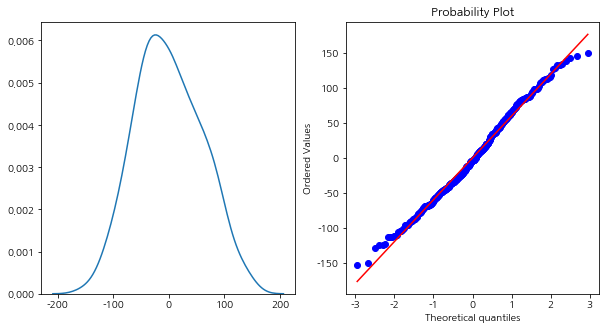

In [121]:
# 1. 정규성 확인
from statsmodels.stats.stattools import jarque_bera

# H0: 모델의 잔차는 정규분포를 따른다. / # H1: 모델의 잔차는 정규분포를 따르지 않는다.
print("정규성 가정확인: ")
stats, p, skew, kurt =jarque_bera(resid) #통계량, p, 왜도, 첨도
print(f"통계량: {stats:.3f}, p-value: {p:.3f}")
print(f"왜도: {skew:.3f} , 첨도: {kurt:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.kdeplot(resid, ax=ax[0])
probplot(resid, plot=ax[1])
plt.show()

jarque beta 검정 결과, 유의수준 5% 하에서 p-value는 충분히 크므로 정규성을 만족하지 않는 것으로 확인되었으며,   
왜도와 첨도도 정규분포의 값(왜도:0, 첨도: 3)에서 다소 차이가 있다.  
잔차의 히스토그램 상에서는 잔차의 분포가 정규분포에 근접한 형태임을 확인할 수 있고, qq-plot 상에도 상 하단에서  
직선을 벗어나는 점들이 미세하게 관찰되기는 하지만 직선 상에 대체로 위치하여 정규분포와 근접함을 알 수 있다.  
**따라서, 정규성을 만족**하는 것으로 판단한다.

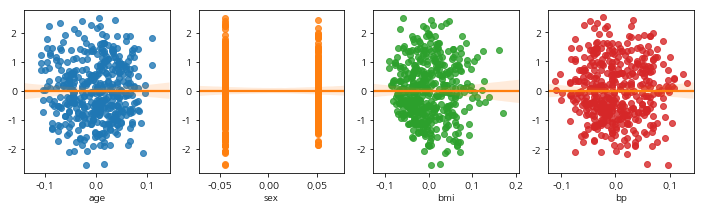

LM Statistic: 6.8939
LM-Test p-value: 0.0754
F-Statistic: 1.7349
F-Test p-value: 0.1412


In [133]:
# 등분산성 확인: 표준화잔차 사용
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for i, col in enumerate(X.columns):
    sns.regplot(x=X[col], y=sresid, ax=ax[i], line_kws={'color': 'C1'})
plt.show()


#H0: 모델의 잔차가 등분산이다. / H1: 모델의 잔차가 등분산이 아니다.
from statsmodels.stats.diagnostic import het_breuschpagan
rs = het_breuschpagan(resid, X)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
for name, value in zip(labels, rs):
    print(f"{name}: {value:.4f}")

각 설명변수의 잔차 그래프에서 독립변수와 잔차의 분산이 일정하면 가운데 회귀선이 수평하게 표시된다.  
표준화 잔차의 절대값이 2를 벗어나면 이상값, 특이값을 예상할 수 있다.   
위 산점도 상에서는 잔차가 등분산을 띄는 것을 확인할 수 있다.  
또한, 라이브러리 검정결과, p-value가 유의수준 5% 하에서 귀무가설을 기각할 수 없어, 잔차가 등분산을 만족한다.

In [135]:
# 독립성 가정 확인
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(resid)
print(f"통계량: {dw:.3f}")

통계량: 1.933


더빈왓슨 독립성 검정의 통계량이 2에 가까우면 잔차간 독립, 0에 가까우면 양의 상관고나계, 4에 가까우면 음의 상관관계로  
2에 가까우므로 잔차간 독립을 만족한다. 

| DW 값 범위        | 해석                               |
| -------------- | -------------------------------- |
| 0 \~ 1.5       | **양(+)의 자기상관 존재 가능성** 높음 (문제 있음) |
| **1.5 \~ 2.5** | **자기상관 없음 (독립성 만족)** → 회귀분석 적합   |
| 2.5 \~ 4       | **음(-)의 자기상관 존재 가능성** (드물게 발생)   |


## 8-1-3. 규제선형회귀

잔차의 최소제곱합을 최소화하도록 회귀계수를 최적화하는 동시에, 패널티함수를 수식에 추가하는 규제를 적용하여 회귀계수의 값들이  
과다추정되는 것을 막아, 모델의 과적합을 방지하는 모델 
- 릿지회귀: 잔차의 최소제곱합에서 회귀계수의 제곱합 항 추가
- 라쏘회귀: 잔차의 최소제곱합에서 회귀계수의 절댓값 항 추가
- 엘라스틱넷: L1, L2 결합방식

규제정도는 사이킷런의 파라미터 alpha로 조정 가능
- 크면: 규제가 커져 모델의 복잡도가 낮아짐(일반화 강화)
- 작으면: 규제가 작아저 모델이 복잡해지며 과적합 가능성 높아짐

| 규제명 (Regularization) | 공식 (Objective Function) |
|--------------------------|----------------------------|
| **Ridge Regression**     | $$ \min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - X_i \beta)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right\} $$ |
| **Lasso Regression**     | $$ \min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - X_i \beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\} $$ |
| **Elastic Net**          | $$ \min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - X_i \beta)^2 + \lambda \left( \alpha \sum_{j=1}^{p} |\beta_j| + (1 - \alpha) \sum_{j=1}^{p} \beta_j^2 \right) \right\} $$ |


### 릿지회귀

작은 데이터셋에서는 선형회귀보다 릿지회귀의 점수가 더 높지만, 데이터가 충분히 많아지면 규제항은 덜 중요해진다.  
중요하지 않은 변수의 회귀계수의 절댓값을 가능한 한 0에 가깝게 규제

In [148]:
# 데이터셋 분할
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

train_X, test_X, train_Y, test_Y = train_test_split(X, Y)

def print_coef(a): #규제정도
    print(f"<규제정도: {a}>")
    rg = Ridge(alpha=a).fit(train_X, train_Y)
    train_s = rg.score(train_X, train_Y)
    test_s = rg.score(test_X, test_Y)
    print(f"train score: {train_s:.3f}, test score: {test_s:.3f}")

    for i, coef in enumerate(rg.coef_):
        print(f"회귀계수 {i}: {coef:.3f}")
    print(f"절편: {rg.intercept_:.3f}")
    
print_coef(0.9)
print_coef(0.1)

<규제정도: 0.9>
train score: 0.254, test score: 0.347
회귀계수 0: 50.069
회귀계수 1: -26.551
회귀계수 2: 351.909
회귀계수 3: 202.176
절편: 150.462
<규제정도: 0.1>
train score: 0.340, test score: 0.492
회귀계수 0: 37.627
회귀계수 1: -103.367
회귀계수 2: 681.237
회귀계수 3: 323.317
절편: 151.604


### 라쏘회귀

L1 규제로 중요하지 않은 계수를 0에 가깝게 만들려고 하며, 실제로 어떤 계수는 0이 된다.(즉 특성이 제거된다.)  
따라서 모델에서 중요한 특성만 남길 수 있다. 일반적으로는 릿지회귀를 선호하지만, 다음과 같은 경우 라쏘를 사용하기도 한다. 
- 특성이 너무 많고, 일부분만 중요
- 분석하기 쉬운 모델 필요

In [149]:
def print_coef2(a): #규제정도
    print(f"<규제정도: {a}>")
    ls = Lasso(alpha=a).fit(train_X, train_Y)
    train_s = ls.score(train_X, train_Y)
    test_s = ls.score(test_X, test_Y)
    print(f"train score: {train_s:.3f}, test score: {test_s:.3f}")

    for i, coef in enumerate(ls.coef_):
        print(f"회귀계수 {i}: {coef:.3f}")
    print(f"절편: {ls.intercept_:.3f}")
    
print_coef2(0.9)
print_coef2(0.1)

<규제정도: 0.9>
train score: 0.233, test score: 0.290
회귀계수 0: 0.000
회귀계수 1: -0.000
회귀계수 2: 455.186
회귀계수 3: 10.134
절편: 150.264
<규제정도: 0.1>
train score: 0.341, test score: 0.496
회귀계수 0: 0.000
회귀계수 1: -65.079
회귀계수 2: 741.969
회귀계수 3: 302.827
절편: 151.590


### 엘라스틱넷

두 규제방식을 결합

In [151]:
from sklearn.linear_model import ElasticNet

def print_coef3(a, l1): #규제정도 a, l1_ratio 는 l1의 비율, 나머지는 l2 비율
    print(f"<규제정도: {a}>")
    ls = ElasticNet(alpha=a, l1_ratio=l1).fit(train_X, train_Y)
    train_s = ls.score(train_X, train_Y)
    test_s = ls.score(test_X, test_Y)
    print(f"train score: {train_s:.3f}, test score: {test_s:.3f}")

    for i, coef in enumerate(ls.coef_):
        print(f"회귀계수 {i}: {coef:.3f}")
    print(f"절편: {ls.intercept_:.3f}")
    
print_coef3(0.1, 0.1)
print_coef3(0.1, 0.9)

<규제정도: 0.1>
train score: 0.020, test score: 0.009
회귀계수 0: 5.083
회귀계수 1: 0.649
회귀계수 2: 19.806
회귀계수 3: 13.442
절편: 149.224
<규제정도: 0.1>
train score: 0.124, test score: 0.155
회귀계수 0: 24.276
회귀계수 1: -0.000
회귀계수 2: 139.453
회귀계수 3: 86.908
절편: 149.665


## 8-1-4. 일반화 선형회귀

정규분포를 따르지 않는 종속변수에 적절한 함수를 적용하여 예측변수에 따라 선형적ㅇ로 변화하도록 하는 회귀모델 기법  
이 때, 종속변수에 적용하는 함수를 연결함수라고 함

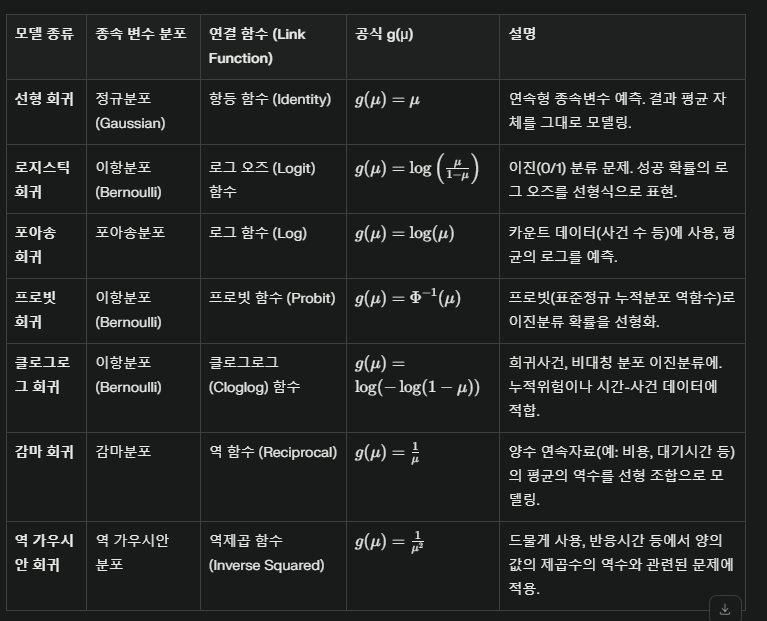

### 로지스틱 회귀

<선형회귀와 비교>

- 공통점: 예측변수와 응답변수 선형관계 가정, 예측변수에 스플라인 변환 사용, 회귀계수 해석을 통해 모델 중요도 정도 확인가능
- 로지스틱 회귀
  - 종속변수에 연결함수 logit function 적용 필요
  - 최대우도추정을 사용해 모델 적합(예상 로그 오즈비)
  - 최적화: Quasi Newton optimization(Fisher's scoring, 적합성 향상방향으로 파라미터 업데이트)
  - 잔차의 특징과 분석 불가능
  
<로지스틱 회귀 장단점>
- 장점: 모델 구현이 쉽고 계산이 빨라 효율적, 다른 분류모델에 비해 모델 해석이 쉬움
- 단점: 이상치에 민감, 표본의 크기가 너무 작으면 추정치가 불안정함

<로지스틱 회귀계수의 해석과 유효성>
- 오즈비: 다른 특성들의 값은 동일한 상태에서 특정한 특성 x가 한 단위 증가하면, 증가 후 y(1이 될 확률)의 오즈가 증가 전 오즈의 exp(x계수)배
- exp(회귀계수)가 1 이상이면, 해당 설명변수 값이 증가할 때, y의 odds와 확률값이 같이 높아지는 양의 인과관계
- 회귀계수 유효성을 검정하기 위해 z 분포 사용(최대우도추정법 사용 시 표본크기가 증가하면 정규분포를 따르는 특성)
  - 통계량: (회귀계수 추정량/회귀계수 추정량의 표준편차)
  - 통계량을 제곱한 왈드 검정통계량(자유도가 1인 카이제곱분포 따름) 사용하여 회귀계수 유효성 검정 가능
  - p-value가 유의수준보다 작고, **귀무가설을 기각** 하면 회귀계수가 0이 아니며, 유효함
  
<로지스틱 회귀모델의 유효성>  
- 우도비 검정을 통해 로그우도비(LLR) 통계량으로 모델 유효성 확인
  - 로그우도비: 상수항만 있는 모델의 최대 로그가능도에서 해당모델의 최대 로그가능도를 뺀 값에 -2를 곱한 값
    - -2*(M0의 로그 가능도 - M1의 로그가능도)   
    - **자유도가 (M1 자유도 - M0 자유도)인 카이제곱 분포**
  - 가설: 
    - H0: null model의 최대로그가능도와 full model의 최대로그가능도는 차이가 없다.
    - H1: full model의 최대로그가능도가 null model의 최대로그가능도보다 크다. 
  - **잔차분석은 불필요함**

In [251]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from collections import Counter

data = load_breast_cancer()

X  = data.data[:, :4]
Y = data.target

X = pd.DataFrame(X, columns=data.feature_names[:4])

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, stratify=Y, random_state=0)

print(Counter(Y))
train_X.shape, test_X.shape

Counter({1: 357, 0: 212})


((426, 4), (143, 4))

In [252]:
# 로지스틱 회귀
lr = LogisticRegression(C=0.01, max_iter=1000) #C가 높을수록 규제가 약해지며, 복잡성 증가
lr.fit(train_X, train_Y)

score1 = lr.score(train_X, train_Y)
score2 = lr.score(test_X, test_Y)

print(f"train score: {score1:.3f} / test score: {score2:.3f}")

ss = 'y = '

for i, coef in enumerate(lr.coef_.ravel()):
     ss += f"{coef:.3f} * {X.columns[i]} + "
ss += f"{lr.intercept_[0]:.3f}"

print(f"회귀식: {ss}")


# classificatin report
from sklearn.metrics import classification_report

pred = lr.predict(train_X)

print(classification_report(train_Y, pred))


# 오즈비 계산
odds_ratios = np.exp(lr.coef_[0])

# 결과를 DataFrame으로 보기 좋게 출력
odds_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Coefficient': lr.coef_[0],
    '오즈비': odds_ratios
})

display(odds_df)

train score: 0.913 / test score: 0.874
회귀식: y = 0.016 * mean radius + -0.192 * mean texture + -0.272 * mean perimeter + 0.008 * mean area + 24.001
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       159
           1       0.91      0.96      0.93       267

    accuracy                           0.91       426
   macro avg       0.91      0.90      0.91       426
weighted avg       0.91      0.91      0.91       426



,Feature,Coefficient,오즈비
0,mean radius,0.016222,1.016355
1,mean texture,-0.191792,0.825478
2,mean perimeter,-0.272485,0.761485
3,mean area,0.008218,1.008252


mean radius의 단위가 1 증가할 때, 이전 오즈에 비해 1.016355 배 오즈가 증가한다.  
- “mean radius가 커질수록 악성일 가능성이 약간씩 높아지는 경향이 있습니다.”

| Feature        | 계수 (Coefficient) | 오즈비 (Odds Ratio) | 해석 방향        | 영향력 크기 |
| -------------- | ---------------- | ---------------- | ------------ | ------ |
| mean radius    | +0.016           | 1.016            | 오즈 증가 (악성 ↑) | 작음     |
| mean texture   | –0.192           | 0.825            | 오즈 감소 (악성 ↓) | 중간     |
| mean perimeter | –0.272           | 0.761            | 오즈 감소 (악성 ↓) | 큼      |
| mean area      | +0.008           | 1.008            | 오즈 증가 (악성 ↑) | 매우 작음  |


최적의 cut-off value: 0.646


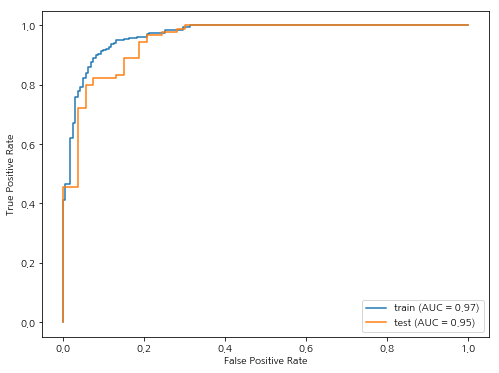

In [253]:
from sklearn.metrics import roc_curve, plot_roc_curve


prob = lr.predict_proba(train_X)
#Youden index: 민감도+특이도-1 공식으로 특이도와 민감도의 합이 최대가 되는 지점 찾기, cut-off value 
fpr, tpr, thresholds = roc_curve(train_Y, prob[:, 1])

j = tpr - fpr
idx = np.argmax(j)
best_threshold = thresholds[idx]
best_tpr = tpr[idx]
best_fpr = fpr[idx]

print(f"최적의 cut-off value: {best_threshold:.3f}")


fig, ax = plt.subplots(1, 1, figsize=(8 ,6))
plot_roc_curve(lr, train_X, train_Y, ax=ax, name='train')
plot_roc_curve(lr, test_X, test_Y, ax=ax, name='test')
plt.show()

In [254]:
# statsmodel: 자동규제 적용으로 사이킷런의 C 큰수 설정(규제없음) 과 비슷

from scipy.stats import chi2
import statsmodels.api as sm

X_train = sm.add_constant(train_X)
model = sm.Logit(train_Y, X_train).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.169550
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  426
Model:                          Logit   Df Residuals:                      421
Method:                           MLE   Df Model:                            4
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                  0.7434
Time:                        21:35:27   Log-Likelihood:                -72.229
converged:                       True   LL-Null:                       -281.44
Covariance Type:            nonrobust   LLR p-value:                 2.906e-89
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1470      8.502      0.017      0.986     -16.516      16.810
mean radius     

In [255]:
# 왠지 모르게 성능이 개같음
# train_Y = pd.Series(train_Y, name='target') 
# train_X.columns = train_X.columns.str.replace(' ', '_')
# train = pd.concat([train_X, train_Y], axis=1)

# sen = "+".join(train_X.columns)
# model = smf.logit(formula=f"target~{sen}", data=train, family=sm.families.Binomial()).fit()

# print(model.summary())

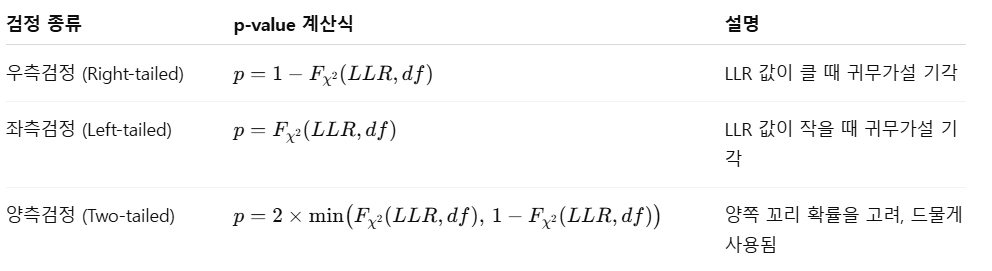

In [256]:
# 유의성 확인
a = 0.05
LLR = -2*(model.llnull - model.llf) #로그우도비(model.llr)
cv = chi2.ppf(1-a, model.df_model) #LLR이 임계값보다 크면 모형 유의
sp = 1 - chi2.cdf(LLR, model.df_model) #right 검정


ll = [(model.llf, 'full model 우도'), (model.llnull, 'null model 우도'), (LLR, '로그우도비'), (cv, '임계값'), 
      (sp, 'p-value'), (model.prsquared, 'R2 설명력')]

for v, n in ll:
    print(f"{n}: {v:.3f}")

full model 우도: -72.229
null model 우도: -281.440
로그우도비: 418.423
임계값: 9.488
p-value: 0.000
R2 설명력: 0.743


In [266]:
# wald 통계량으로 회귀계수 유의성 검증
z = model.params['mean radius'] / model.bse['mean radius']

w_stat = z**2

cv = chi2.ppf(1-a, 1)
sp = 1- chi2.cdf(w_stat, 1)

print(f"z통계량: {z:.3f}")
print(f"wald 통계량: {w_stat:.3f}, 임계값: {cv:.3f}")
print(f"유의확률: {sp:.3f}")

z통계량: 4.906
wald 통계량: 24.072, 임계값: 3.841
유의확률: 0.000


1. 모델 적합 정보
- 관측치 수 (No. Observations): 426개
- 모델 종류: Logit (로지스틱 회귀)
- 최대 우도 (Log-Likelihood): -72.229 (모델 적합도 지표 중 하나)
- Null 모델 우도 (LL-Null): -281.44 (변수 없이 절편만 있는 모델)
- Pseudo R-squared (의사결정계수): 0.7434 → 꽤 좋은 설명력 (1에 가까울수록 좋음)
- LLR p-value: 2.906e-89 → 모델 전체가 통계적으로 매우 유의함 (p < 0.05)

2. 계수(coef) 해석
- mean radius (평균 반지름): 10.3953, p < 0.001 → 양의 강한 영향, 클수록 종속변수가 1(예: 악성 종양)일 확률 크게 증가
- mean texture (평균 질감): -0.2622, p < 0.001 → 음의 영향, 값이 클수록 종속변수가 1일 확률 감소
- mean perimeter (평균 둘레): -1.3234, p < 0.001 → 음의 영향
- mean area (평균 면적): -0.0317, p=0.032 → 약간의 음의 영향, 통계적으로 유의

3. 모델 성능과 주의사항
- Pseudo R-squared 0.7434 → 모델이 데이터를 꽤 잘 설명하고 있음
- LLR p-value 매우 작음 → 모델 전체 유의
- quasi-separation 경고

일부 데이터가 거의 완벽하게 분류됨 → 계수 추정치가 불안정할 수 있음  
즉, 독립변수 조합으로 결과가 거의 완벽히 나누어지는 상태  
이럴 때는 계수값이 과도하게 크거나, 표준 오차가 클 수 있음  
예: mean radius의 계수가 매우 크고 표준오차도 큰 편임  

4. 요약
- 모델 성능은 좋음 (높은 Pseudo R-squared, 유의한 변수들)
- 다만 일부 변수에 대해 완전 분리 문제(quasi-separation)가 있어 계수 불안정 가능
- 이럴 때는 더 많은 데이터, 변수 선택, 혹은 규제(regularization)를 고려할 수 있음

### 포아송 회귀

종속변수가 포아송 분포를 따른다고 가정하고, 일반화 선형모형의 회귀분석을 수행하는 것으로, 종속변수가 빈도데이터일 때 주로 사용

<가정>
- 종속변수는 빈도 데이터
- 동일한 길이의 어떤 두 구간에서 사건발생확률은 동일
- 어떤 구간에서 사건 발생이 다른 구간의 사건발생과 독립
- 어떤 짧은 구간에서 두 개 이상의 결과가 동시에 나올 확률은 0

<해석>
- 다른 특성을 고정한 상태에서 한 특성이 한 단위 증가했을 때 종속변수의 빈도 수가 exp(회귀배수)배 증가
- 회귀계수 유효성 검정은 z분포를 사용하여 검정(최대우도추정법을 사용하기 때문)
- 마찬가지로 왈드 검정통계량은 자유도가 1인 카이제곱분포 따름

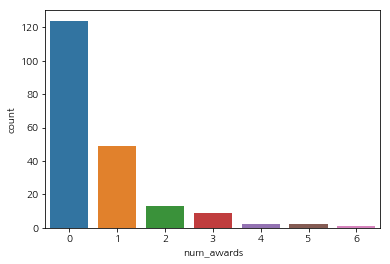

In [275]:
from sklearn.linear_model import PoissonRegressor


award = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/8-1-4_awards.csv')

Y = award['num_awards']
X = award[['prog', 'math']] #prog는 카테고리형
X = pd.get_dummies(X, columns=['prog'], drop_first=True) #다중공선성 방지

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=0)

sns.countplot(Y)
plt.show()

In [282]:
#포아송 회귀

pr = PoissonRegressor(alpha=0.2) #클수록 규제가 커지고, 0이면 규제가 없다.
pr.fit(train_X, train_Y)

s1 = pr.score(train_X, train_Y)
s2 = pr.score(test_X, test_Y)

print(f"train score: {s1:.3f}, test score: {s2:.3f}")

pred = pr.predict(X)
rs = pd.DataFrame()
rs['pred'] = pred
rs['y'] = Y

display(rs.head(3))

ss = 'y = '

for i, coef in enumerate(pr.coef_.ravel()):
     ss += f"{coef:.3f} * {X.columns[i]} + "
ss += f"{pr.intercept_:.3f}"

print(f"회귀식: {ss}")

# 오즈비 계산
odds_ratios = np.exp(pr.coef_[0])

# 결과를 DataFrame으로 보기 좋게 출력
odds_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Coefficient': pr.coef_[0],
    '오즈비': odds_ratios
})

display(odds_df)

train score: 0.327, test score: 0.301


,pred,y
0,0.139911,0
1,0.157514,0
2,0.176883,0


회귀식: y = 0.078 * math + 0.311 * prog_2 + -0.119 * prog_3 + -5.053


,Feature,Coefficient,오즈비
0,math,0.078162,1.081297
1,prog_2,0.078162,1.081297
2,prog_3,0.078162,1.081297


math가 1점 증가하면, 빈도수가 1.081배 된다.

In [286]:
X_train = sm.add_constant(train_X)
model = sm.GLM(train_Y, X_train, family=sm.families.Poisson()).fit()

a = 0.05
cv = chi2.ppf(1-a, model.df_resid) #right 검정
print(f"임계치: {cv:.3f}")

print(model.summary())

임계치: 175.198
                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  150
Model:                            GLM   Df Residuals:                      146
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -136.21
Date:                Mon, 21 Jul 2025   Deviance:                       140.62
Time:                        22:13:01   Pearson chi2:                     163.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4088
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.2428      0.777     -6

In [287]:
# wald 통계량으로 회귀계수 유의성 검증
z = model.params['math'] / model.bse['math']

w_stat = z**2

cv = chi2.ppf(1-a, 1)
sp = 1- chi2.cdf(w_stat, 1)

print(f"z통계량: {z:.3f}")
print(f"wald 통계량: {w_stat:.3f}, 임계값: {cv:.3f}")
print(f"유의확률: {sp:.3f}")

z통계량: 5.610
wald 통계량: 31.473, 임계값: 3.841
유의확률: 0.000


| 항목               | 값                                                       | 설명 및 해석                                                          |
| ---------------- | ------------------------------------------------------- | ---------------------------------------------------------------- |
| **임계치**          | 175.198                                                 | (질문에 나온 임계치인데, 모델 출력에 직접 관련은 없음 — 보통 검정 통계량과 비교에 사용)             |
| **종속 변수**        | num\_awards                                             | 수상 개수 (포아송 분포를 가정한 카운트형 변수)                                      |
| **관측치 수**        | 150                                                     | 데이터 샘플 수                                                         |
| **모델 종류**        | GLM (포아송)                                               | 일반화 선형 모델, 포아송 분포, 로그 링크 함수 사용                                   |
| **회귀계수(β)**      |                                                         |                                                                  |
| const            | -5.2428                                                 | 절편, 모든 설명변수가 0일 때 로그 기대 수상 개수 (log scale)                        |
| math             | 0.0673                                                  | 수학 점수 한 단위 증가 시, 기대 수상 개수가 exp(0.0673)=1.07배 증가                  |
| prog\_2          | 1.2926                                                  | prog\_2 그룹(더미변수)일 때, 기대 수상 개수가 exp(1.2926)=3.64배 증가              |
| prog\_3          | 0.2927                                                  | prog\_3 그룹일 때, 기대 수상 개수가 exp(0.2927)=1.34배 증가 (유의하지 않음, p=0.608) |
| **표준오차**         | const 0.777, math 0.012, prog\_2 0.472, prog\_3 0.570   | 각 계수의 추정치 신뢰도 척도                                                 |
| **z값**           | const -6.748, math 5.610, prog\_2 2.740, prog\_3 0.513  | 계수 유의성 테스트 통계량                                                   |
| **p값**           | const <0.001, math <0.001, prog\_2 0.006, prog\_3 0.608 | 통계적으로 유의한지 판단 (0.05 미만이면 유의)                                     |
| **신뢰구간**         | 각 계수별 95% 신뢰구간 제공                                       | 계수 추정치가 포함될 신뢰 구간                                                |
| **Deviance**     | 140.62                                                  | 모델 적합도 지표 (낮을수록 좋음)                                              |
| **Pearson chi2** | 163.0                                                   | 잔차의 Pearson 카이제곱 통계량                                             |
| **Pseudo R²**    | 0.4088                                                  | 의사결정계수 (모형 설명력, 40.88% 수준)                                       |


## 8-1-5. 이상치에 강한 선형회귀

### Robust regression
일반적으로 선형 회귀 모델에서 회귀계수를 추정할 때 최소 제곱법을 사용한다. 이 경우 데이터 이상치에 의해 전체 추정치가 왜곡될 수  
있다. 이 방식은 문제해결 대안으로 잔차의 제곱 대신 절대값의 합이 최소가 되도록 계수를 추정함으로써 이상치의 영향력을 줄인다.

In [329]:
from sklearn.linear_model import HuberRegressor
from sklearn.datasets import make_regression

rng = np.random.RandomState(0)

X, Y = make_regression(n_samples=30, n_features=1, random_state=0, noise=4.0, bias=100.0)


# outterlier 추가
X_out = rng.normal(0, 0.5, size=(4, 1))
Y_out = rng.normal(0, 2.0, size=4)

X_out[:2, :] += X.max() + X.mean() #반은 더 크게
X_out[2:, :] += X.min() - X.mean() # 더 작게
Y_out[:2] += Y.max() + Y.mean() #반은 더 크게
Y_out[2:] += Y.min() - Y.mean() # 더 작게

X = np.vstack((X, X_out)) # 행방향 결합
Y = np.concatenate((Y, Y_out))

In [330]:
# 로버스트 모델
hr = HuberRegressor(epsilon=1).fit(X, Y)
pred1 = hr.predict(X)

# 선형회귀
lr = LinearRegression().fit(X, Y)
pred2 = lr.predict(X)

print(f"로버스트 coef: {hr.coef_}, score: {hr.score(X, Y):.3f}")
print(f"선형회귀 coef: {lr.coef_}, score: {lr.score(X, Y):.3f}")

로버스트 coef: [96.42398614], score: 0.924
선형회귀 coef: [112.4357568], score: 0.945


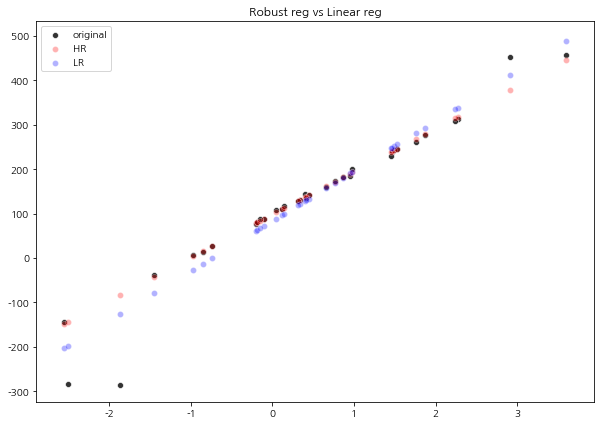

In [331]:
# 비교
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

sns.scatterplot(X.flatten(), Y, color='black', alpha=0.8, markers='x', label='original')
sns.scatterplot(X.flatten(), pred1, color='r', alpha=0.3, markers='o', label='HR')
sns.scatterplot(X.flatten(), pred2, color='b', alpha=0.3, markers='<', label='LR')
ax.set_title('Robust reg vs Linear reg')
plt.show()

### Quantile regression

특정 분위값을 추정하는 기법으로, 50% 분위값을 추정하는 모델을 만들면 이상치으 영향을 거의 받지 않게 됨.  
이분산 데이터도 이 회귀기법으로 모델링 가능  
L1 규제 적용을 alpha를 통해 조절할 수 있음
=> 라이브러리 안먹음

# 8-2. 비선형회귀

응답변수와 예측변수 간 관계가 비선형일 때 사용

### 다항회귀
2차 함수 이상의 다항함수를 이용하여 두 변수간의 관계 설명

R2: 0.896


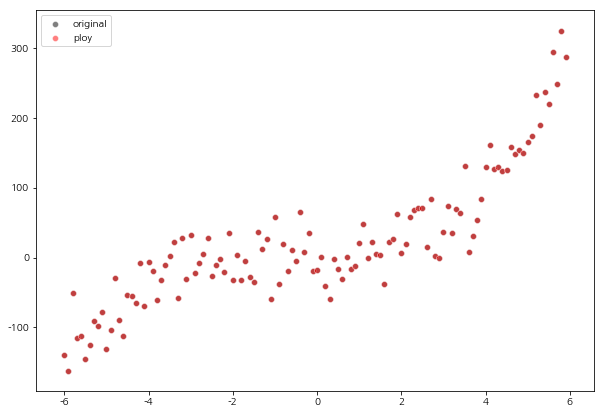

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     334.9
Date:                Mon, 21 Jul 2025   Prob (F-statistic):           6.04e-57
Time:                        23:00:16   Log-Likelihood:                -578.58
No. Observations:                 120   AIC:                             1165.
Df Residuals:                     116   BIC:                             1176.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9769      4.185     -0.233      0.8

In [347]:
X = np.arange(-6.0, 6.0, 0.1)
Y = 1*(X**3) + 2*(X**2) + 1*X + 3 #다항식
ns = 30 * np.random.normal(size=X.size) #노이즈
Y = Y + ns

from sklearn.preprocessing import PolynomialFeatures

poly_f = PolynomialFeatures(degree=3, include_bias=True) #차수, 절편추가여부
px = poly_f.fit_transform(X.reshape(-1, 1)) #2차원 변환값을 입력값으로

lr = LinearRegression()
lr.fit(px, Y)
pred = lr.predict(px)

print(f"R2: {lr.score(px, Y):.3f}")

#원본과 비교
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

sns.scatterplot(X, Y, alpha=0.5, color='black', label='original', ax=ax)
sns.scatterplot(X, Y, alpha=0.5, color='r', label='ploy', ax=ax)
plt.show()


#statsmodel

model = sm.OLS(Y, px).fit()

print(model.summary())

### 스플라인 회귀

다항 구간들을 부드러운 곡선 형태로 적합하는 방식, 스플라인 구간을 구분하는 값을 매듭(Knot)이라고 한다. => 안됨

# 연습문제

### 1. 다음은 인도 벵갈루루의 집값 데이터이다. 데이터는 집의 특징을 나타내는 입력 변수들과 집값의 m출력 변수로 구성되어 있다. 데이터 컬럼 정의는 아래와 같을 때, 선형 회귀 분석을 수행하시오. (데이터 링크는 아래 코드 참조)

입력 변수]
1. availability: 즉시 입주 가능한 여부
2. size: 방, 거실, 주방 구성에 따른 집 크기 등급
3. bath: 화장실 개수
4. balcony: 발코니 개수
5. total_sqft: 전체 면적
6. area_type: Carpet, Plot, Super built-up, built-up의 범주로 이루어진 범주형 변수.

   [출력 변수]
7. price: 집 가격

   [출처] Kaggle, https://www.kaggle.com/datasets/aryanfelix/bangalore-housing-prices

In [355]:
dt= pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/practice8_BHP2.csv')
print(dt.info())
display(dt.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7495 entries, 0 to 7494
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     7495 non-null   object 
 1   availability  7495 non-null   int64  
 2   size          7495 non-null   int64  
 3   total_sqft    7495 non-null   float64
 4   bath          7495 non-null   int64  
 5   balcony       7495 non-null   int64  
 6   price         7495 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 410.0+ KB
None


,area_type,availability,size,total_sqft,bath,balcony,price
0,Super,0,3,1056.0,2,1,39.07
1,Plot,1,6,2600.0,5,3,120.00
2,Super,1,5,1521.0,3,1,95.00


In [357]:
dt.isna().sum()

area_type       0
availability    0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [386]:
dt.columns

Index(['area_type', 'availability', 'size', 'total_sqft', 'bath', 'balcony',
       'price'],
      dtype='object')

In [388]:
#일단 선형회귀 수행
from sklearn.metrics import r2_score

X = dt[dt.columns[:-1]]
Y = dt['price']

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=11)

formula = "price~C(area_type)+C(availability)+size+total_sqft+bath+balcony"
train = pd.concat([train_X, train_Y], axis=1)

model = smf.ols(formula=f"{formula}", data=train).fit()

print(model.summary())

# 결정계수 확인
pred = model.predict(test_X)
s = r2_score(test_Y, pred)
print(f"score: {s:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     656.3
Date:                Tue, 22 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:00:22   Log-Likelihood:                -32305.
No. Observations:                5621   AIC:                         6.463e+04
Df Residuals:                    5612   BIC:                         6.469e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                -62

유의수준 5% 하에서 귀무가설을 기각(정규성x)
정규성 가정확인: 
통계량: 17235471.266, p-value: 0.000
왜도: 8.209 , 첨도: 273.778


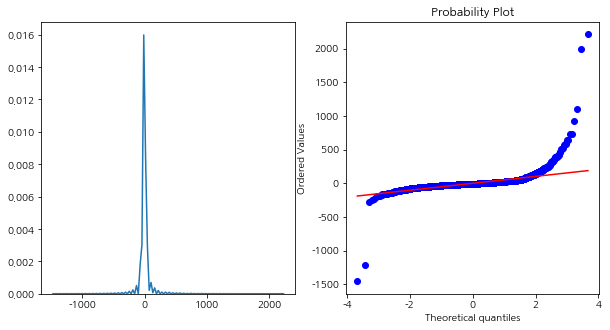

In [391]:
# 선형회귀 가정 만족여부 확인: 잔차
# 정규성: shapiro wilk test
stat, p = shapiro(model.resid)
print(f"유의수준 5% 하에서 귀무가설을", "기각(정규성x)" if p < 0.05 else "기각x(정규성)")

from statsmodels.stats.stattools import jarque_bera
# H0: 모델의 잔차는 정규분포를 따른다. / # H1: 모델의 잔차는 정규분포를 따르지 않는다.
print("정규성 가정확인: ")
stats, p, skew, kurt =jarque_bera(model.resid) #통계량, p, 왜도, 첨도
print(f"통계량: {stats:.3f}, p-value: {p:.3f}")
print(f"왜도: {skew:.3f} , 첨도: {kurt:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.kdeplot(model.resid, ax=ax[0])
probplot(model.resid, plot=ax[1])
plt.show() # 정규성을 만족하지 않는다. ...

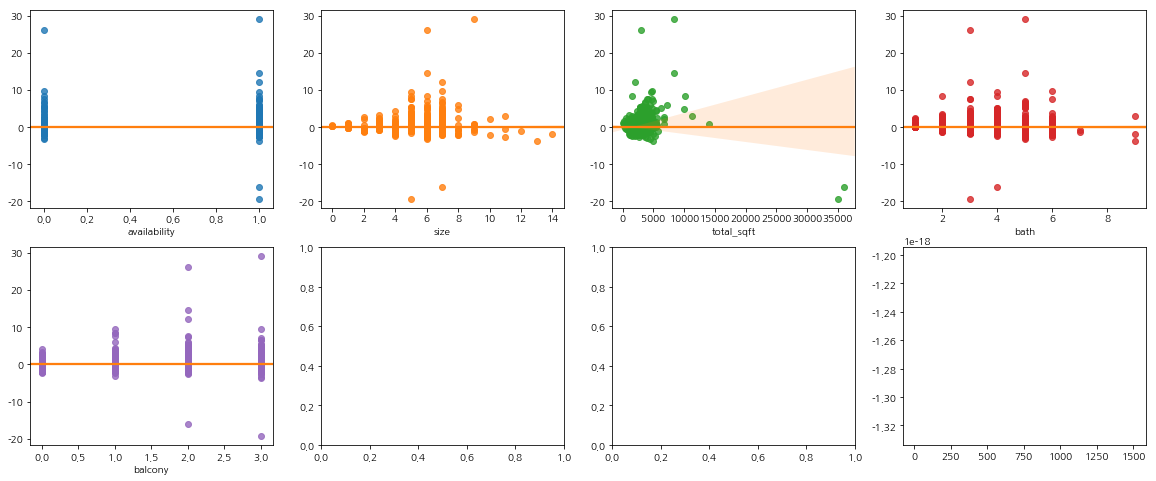

LM Statistic: 978.0485
LM-Test p-value: 0.0000
F-Statistic: 147.7726
F-Test p-value: 0.0000


In [392]:
# 등분산성 확인: 표준화잔차 사용

sresid = zscore(model.resid)

fig, ax = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(X.columns[1:]):
    x = i // 4
    y = i % 4
    sns.regplot(x=train_X[col], y=sresid, ax=ax[x, y], line_kws={'color': 'C1'})
plt.show()


#H0: 모델의 잔차가 등분산이다. / H1: 모델의 잔차가 등분산이 아니다.
from statsmodels.stats.diagnostic import het_breuschpagan
rs = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
for name, value in zip(labels, rs):
    print(f"{name}: {value:.4f}")

위 산점도 상에서는 잔차가 등분산을 띄지 않는다.
또한, 라이브러리 검정결과, p-value가 유의수준 5% 하에서 귀무가설을 기각하여, 잔차가 등분산을 만족하지 않는다.

In [393]:
# 독립성 가정 확인
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid)
print(f"통계량: {dw:.3f}")
print("2에 가까우므로 독립성은 만족한다.")

통계량: 2.043
2에 가까우므로 독립성은 만족한다.


모델 자체의 학습결과는 Prob (F-statistic): 0.00으로 유의수준 5% 하에서 모델은 통계적으로 유의하며, 약 48.3%의 설명력을 가진다.  
또한 size, balcony, area_type_Carpet, area_type_Super, availability_1 변수가 통계적으로 유의하지 않는 것으로 확인되었다.  


잔차 분석 결과, 이 모델은 정규성 및 등분산성 가정을 만족하지 않습니다. 이러한 가정이 위배되면 회귀계수의 신뢰성과 예측 정확도가 저하될 수 있으며, 이는 선형 회귀 모델로서의 적합성을 떨어뜨린다.

**본 선형 회귀 모델은 전체적으로 통계적으로 유의하며, 약 48.3%의 설명력을 가지고 있다. 그러나 size, balcony, area_type_Carpet, area_type_Super, availability_1 변수는 유의하지 않은 것으로 나타났다. 또한, 잔차 분석 결과 정규성과 등분산성의 가정을 만족하지 않아 본 모델은 해석 및 예측 측면에서 한계가 있으며, 보다 적절한 대안 모델이 필요하다.**

### 2. 앞선 모델에서 변수 area_type과 total_sqft의 교호작용항을 추가하여 회귀분석을 수행하시오.

#### ▷ 교호작용(interaction term)의 사용 필요성을 판단하는 기준

- 1) 이론적/도메인 기반 필요성
    - 변수 간 효과가 독립적이지 않다고 가정되거나 알려져 있는 경우.
    - 예를 들어:
        - 약물 효과는 용량(dose) 과 성별(gender) 의 조합에 따라 달라질 수 있음.
        - 마케팅 효과는 나이 와 채널 이 결합될 때 다르게 작동할 수 있음.
- 2) EDA
    - scatter plot, box plot, line plot 등을 활용하여 한 변수의 효과가 다른 변수의 값에 따라 기울기나 패턴이 달라지는 경우.
    - 예시: 범주형 A에 따라 연속형 X와 Y의 관계선이 평행하지 않으면 교호작용 가능성↑.

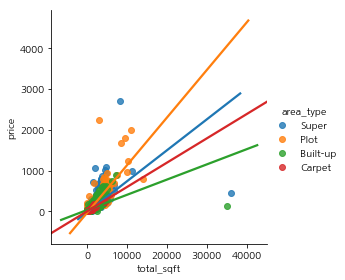

In [394]:
#area_type에 따른 total_sqft와 price의 관계
sns.lmplot(data =dt, x='total_sqft', y='price', ci=None, hue='area_type', height=4);

In [396]:
#교호작용항 추가

intercep = '+C(area_type):total_sqft'
formula = formula+intercep

model2 = smf.ols(formula=f"{formula}", data=train).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     556.3
Date:                Tue, 22 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:04:07   Log-Likelihood:                -32088.
No. Observations:                5621   AIC:                         6.420e+04
Df Residuals:                    5609   BIC:                         6.428e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

이전 모델에 비해 성능이 다소 향상되었다. 
- 설명력: 52.2%로 증가

### 3. 앞선 모델에서 변수 total_sqft의 이차항을 추가하여 회귀분석을 수행하시오.

In [398]:
#이차항 추가

intercep = '+I(total_sqft**2)'
formula = formula+intercep

model3 = smf.ols(formula=f"{formula}", data=train).fit()

print(model3.summary())

# 결정계수 확인
pred = model3.predict(test_X)
s = r2_score(test_Y, pred)
print(f"score: {s:.3f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     847.8
Date:                Tue, 22 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:09:48   Log-Likelihood:                -31254.
No. Observations:                5621   AIC:                         6.253e+04
Df Residuals:                    5608   BIC:                         6.262e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

모델의 설명력이 64.5%로 다소 증가하였으며, 예측 성능도 0.731로 향상

In [420]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

vif_df = pd.DataFrame(columns=['feat', 'VIF'])

vif_df['feat'] = model3.model.exog_names  # 변수 이름 포함
vif_df['VIF'] = [VIF(model3.model.exog, i) for i in range(model3.model.exog.shape[1])]

vif_df = vif_df.sort_values(by='VIF', ascending=False)

display(vif_df)  #total_sqft 삭제

formula = 'price~C(area_type)+C(availability)+size+bath+balcony+C(area_type):total_sqft+C(area_type):total_sqft+I(total_sqft**2)'

model4 = smf.ols(formula=f"{formula}", data=train).fit()


print(model4.summary())

# 결정계수 확인
pred = model4.predict(test_X)
s = r2_score(test_Y, pred)
print(f"score: {s:.3f}")


# 유의하지 않은 변수 삭제
from sklearn.preprocessing import StandardScaler

n_cols = ['size', 'total_sqft', 'bath', 'balcony']

sc = StandardScaler()

train_X[n_cols] = sc.fit_transform(train_X[n_cols])

d_col = ['availability', 'bath'] #삭제컬럼

formula = 'price~C(area_type)+size+total_sqft+balcony+C(area_type):total_sqft+C(area_type):total_sqft+I(total_sqft**2)'
model5= smf.ols(formula=f"{formula}", data=train).fit()


print(model5.summary())

# 결정계수 확인
pred = model5.predict(test_X)
s = r2_score(test_Y, pred)
print(f"score: {s:.3f}")

,feat,VIF
0,Intercept,30.557864
6,total_sqft,12.875732
12,I(total_sqft ** 2),5.909911
8,C(area_type)[T.Plot]:total_sqft,5.755264
9,C(area_type)[T.Super]:total_sqft,5.041376
10,bath,4.303239
2,C(area_type)[T.Plot],4.253109
1,C(area_type)[T.Carpet],3.794361
7,C(area_type)[T.Carpet]:total_sqft,3.752646
3,C(area_type)[T.Super],3.319083


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     847.8
Date:                Tue, 22 Jul 2025   Prob (F-statistic):               0.00
Time:                        00:44:26   Log-Likelihood:                -31254.
No. Observations:                5621   AIC:                         6.253e+04
Df Residuals:                    5608   BIC:                         6.262e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

통계적으로 유의하지 않은 변수를 삭제하였을 때, 예측률이 미세하게 상승하였다.